## `inspect_holimocks`

Notebook to read and visualize Mock catalog properties

In [1]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table

In [2]:
root_mocks = Path('/global/cfs/cdirs/desicollab/cosmosim/SecondGenMocks/EZmock/CutSky_6Gpc')

In [12]:
os.listdir(root_mocks/'ELG'/'z1.100'/'NGC_veto')
file = 'EZmock_ELG_z1.100_AbacusSummit_base_c000_ph000_NGC_0911.fits.gz'
path = root_mocks/'ELG'/'z1.100'/'NGC_veto'/file

In [13]:
tbl = fio.FITS(path)

In [14]:
print(tbl[1].get_colnames())
print(tbl[1].get_nrows())
coords = SkyCoord(
    tbl[1]['RA'].read()*u.deg,
    tbl[1]['DEC'].read()*u.deg,
    frame='icrs'
)

['RA', 'DEC', 'Z', 'Z_COSMO', 'RAN_NUM_0_1', 'STATUS', 'MASKBITS', 'NOBS_G', 'NOBS_R', 'NOBS_Z']
75409349


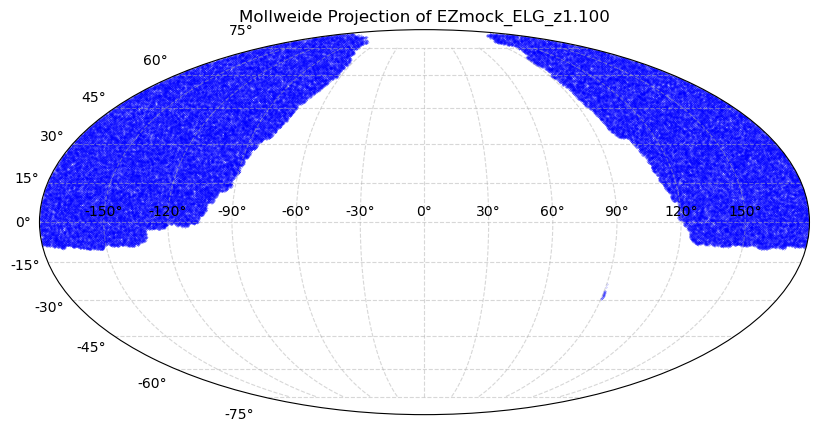

In [15]:
ra = coords.ra.wrap_at(180 * u.deg).radian
dec = coords.dec.radian                     

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

ax.scatter(ra[0::500], dec[0::500], s=0.05, color='blue', alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title("Mollweide Projection of EZmock_ELG_z1.100")

plt.show()